In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from tqdm import tqdm
import pickle
import seaborn as sns

In [2]:
!git clone https://github.com/varaiitj2527/PRMLProject.git
%cd PRMLProject

Cloning into 'PRMLProject'...
remote: Enumerating objects: 212, done.
remote: Counting objects: 100% (194/194), done.
remote: Compressing objects: 100% (168/168), done.
remote: Total 212 (delta 81), reused 38 (delta 11), pack-reused 18 (from 2)
Receiving objects: 100% (212/212), 211.52 MiB | 15.63 MiB/s, done.
Resolving deltas: 100% (81/81), done.
Updating files: 100% (52/52), done.
Filtering content: 100% (16/16), 1.40 GiB | 57.54 MiB/s, done.
/content/PRMLProject


In [3]:
def unpickle(file):
    with open(file, 'rb') as f:
        return pickle.load(f)

In [4]:
X_train_knn_qui=unpickle("PreProcessedData/quicknet_train.pkl")
X_train_knn_qui = np.array(X_train_knn_qui)
print(X_train_knn_qui.shape)
y_train=unpickle("PreProcessedData/Labels_train.pkl")
print(y_train.shape)
X_test_knn_qui=unpickle("PreProcessedData/quicknet_test.pkl")
X_test_knn_qui = np.array(X_test_knn_qui)
y_test=unpickle("PreProcessedData/Labels_test.pkl")

(50000, 512)
(50000,)


In [6]:
import numpy as np
from collections import Counter
from sklearn.metrics import confusion_matrix, accuracy_score
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm

def find_knn(k=10, X_train=X_train_knn_qui, X_test=X_test_knn_qui, y_train=y_train, y_test=y_test):
    results = []

    for idx, test_sample in enumerate(tqdm(X_test)):
        # Compute distances in a vectorized way
        distances = np.linalg.norm(X_train - test_sample, axis=1)

        # Get indices of k smallest distances
        k_nearest_indices = np.argsort(distances)[:k]

        # Get labels of k nearest neighbors
        k_labels = y_train[k_nearest_indices]

        # Majority vote for classification
        predicted_label = Counter(k_labels).most_common(1)[0][0]
        results.append(predicted_label)

    # Compute and print accuracy
    accuracy = accuracy_score(y_test, results)
    print(f"Accuracy: {accuracy * 100:.2f}%")

    # Compute and print confusion matrix
    conf_matrix = confusion_matrix(y_test, results)
    print("Confusion Matrix:\n", conf_matrix)

    # Plot confusion matrix
    plt.figure(figsize=(8, 6))
    sns.heatmap(conf_matrix, annot=True, fmt="d", cmap="Blues",
                xticklabels=np.unique(y_test), yticklabels=np.unique(y_test))
    plt.xlabel("Predicted Label")
    plt.ylabel("True Label")
    plt.title("Confusion Matrix")
    plt.show()

100%|██████████| 10000/10000 [17:42<00:00,  9.42it/s]


Accuracy: 72.64%
Confusion Matrix:
 [[783   9  38  20  18   6  12   9  77  28]
 [ 10 828   8  11   6   7   9   3  42  76]
 [ 67   1 573  55 149  66  47  16  19   7]
 [ 22   6  58 536  92 162  67  18  21  18]
 [ 28   4  38  52 778  19  41  31   8   1]
 [ 11   4  51 177  77 594  31  42   9   4]
 [  8   2  36  62  90  19 763   5  12   3]
 [ 15   1  37  52  96  49   8 727   5  10]
 [ 48  14  12  18   6   4   6   6 871  15]
 [ 30  57  11  17   9   9   9  13  34 811]]


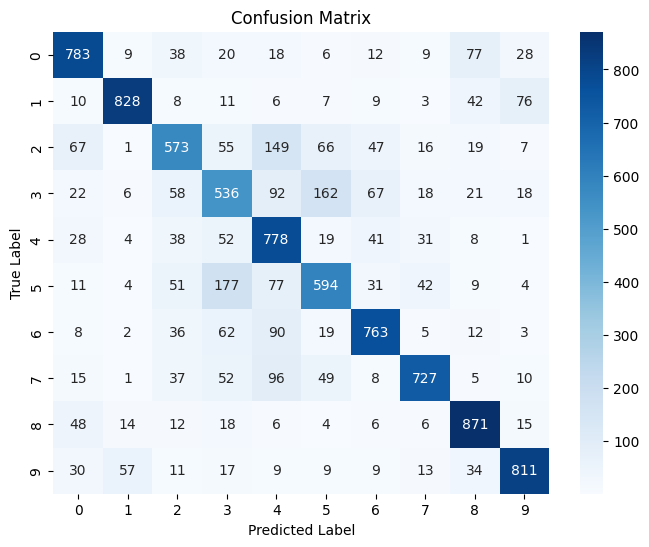

In [7]:
find_knn()

using SkLearn Library with Euclidean as the distance metric

In [8]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

def find_knn1(k=10, X_train=X_train_knn_qui, X_test=X_test_knn_qui, y_train=y_train, y_test=y_test):
    # Initialize k-NN classifier
    knn = KNeighborsClassifier(n_neighbors=k, metric='euclidean')

    # Train the model
    knn.fit(X_train, y_train)

    # Predict on test data
    y_pred = knn.predict(X_test)

    # Compute and print accuracy
    accuracy = accuracy_score(y_test, y_pred)
    print(f"Accuracy: {accuracy * 100:.2f}%")

    # Compute and print confusion matrix
    conf_matrix = confusion_matrix(y_test, y_pred)
    print("Confusion Matrix:\n", conf_matrix)

    # Plot confusion matrix
    plt.figure(figsize=(8, 6))
    sns.heatmap(conf_matrix, annot=True, fmt="d", cmap="Blues",
                xticklabels=np.unique(y_test), yticklabels=np.unique(y_test))
    plt.xlabel("Predicted Label")
    plt.ylabel("True Label")
    plt.title("Confusion Matrix")
    plt.show()


Accuracy: 72.53%
Confusion Matrix:
 [[798  13  34  18  14   7  10   8  76  22]
 [ 15 835   6  12   5   7   8   3  39  70]
 [ 75   2 583  56 145  59  44  14  16   6]
 [ 26   6  62 561  92 148  57  16  17  15]
 [ 31   4  49  58 776  14  33  28   7   0]
 [ 13   5  61 205  74 569  27  35   8   3]
 [ 13   2  44  72  89  15 750   4   9   2]
 [ 16   1  45  56  99  42   6 723   5   7]
 [ 50  16  13  21   6   3   7   5 867  12]
 [ 34  69  12  20   8   7  10  14  35 791]]


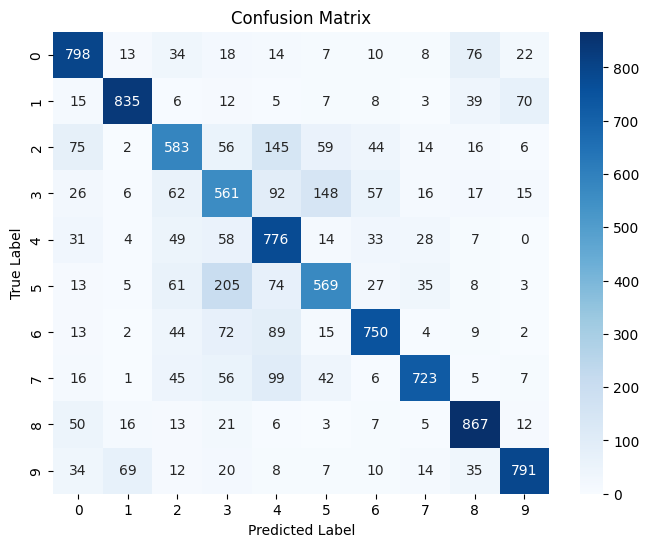

In [9]:
find_knn1()

using SkLearn Library with manhattan as the distance metric

In [10]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

def find_knn2(k=10, X_train=X_train_knn_qui, X_test=X_test_knn_qui, y_train=y_train, y_test=y_test):
    # Initialize k-NN classifier with Manhattan distance
    knn = KNeighborsClassifier(n_neighbors=k, metric='manhattan')

    # Train the model
    knn.fit(X_train, y_train)

    # Predict on test data
    y_pred = knn.predict(X_test)

    # Compute and print accuracy
    accuracy = accuracy_score(y_test, y_pred)
    print(f"Accuracy: {accuracy * 100:.2f}%")

    # Compute and print confusion matrix
    conf_matrix = confusion_matrix(y_test, y_pred)
    print("Confusion Matrix:\n", conf_matrix)

    # Plot confusion matrix
    plt.figure(figsize=(8, 6))
    sns.heatmap(conf_matrix, annot=True, fmt="d", cmap="Blues",
                xticklabels=np.unique(y_test), yticklabels=np.unique(y_test))
    plt.xlabel("Predicted Label")
    plt.ylabel("True Label")
    plt.title("Confusion Matrix")
    plt.show()


Accuracy: 72.61%
Confusion Matrix:
 [[829  12  37  22   8   4   5   6  60  17]
 [ 23 841   8  11   3   0   6   3  37  68]
 [ 94   2 602  67 116  39  38  22  15   5]
 [ 32   5  84 571  71 129  55  15  24  14]
 [ 35   4  58  79 726  22  38  26  11   1]
 [ 16   4  62 215  67 562  27  34   8   5]
 [ 10   4  56  90  68  14 735   6  16   1]
 [ 22   1  49  68  72  34   5 735   7   7]
 [ 58  12  12  24   3   2   8   5 863  13]
 [ 42  57   7  19   5   2  13  12  46 797]]


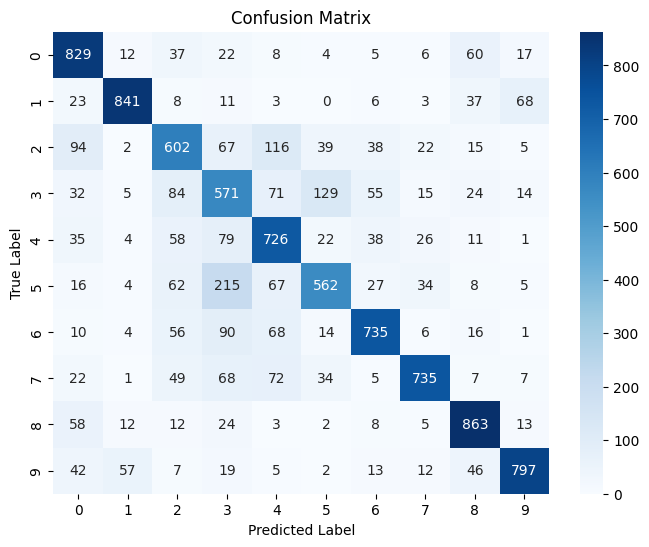

In [11]:
find_knn2()

using SkLearn Library with Canberra as the distance metric

In [12]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

def find_knn3(k=10, X_train=X_train_knn_qui, X_test=X_test_knn_qui, y_train=y_train, y_test=y_test):
    # Initialize k-NN classifier with Canberra distance
    knn = KNeighborsClassifier(n_neighbors=k, metric='canberra')

    # Train the model
    knn.fit(X_train, y_train)

    # Predict on test data
    y_pred = knn.predict(X_test)

    # Compute and print accuracy
    accuracy = accuracy_score(y_test, y_pred)
    print(f"Accuracy: {accuracy * 100:.2f}%")

    # Compute and print confusion matrix
    conf_matrix = confusion_matrix(y_test, y_pred)
    print("Confusion Matrix:\n", conf_matrix)

    # Plot confusion matrix
    plt.figure(figsize=(8, 6))
    sns.heatmap(conf_matrix, annot=True, fmt="d", cmap="Blues",
                xticklabels=np.unique(y_test), yticklabels=np.unique(y_test))
    plt.xlabel("Predicted Label")
    plt.ylabel("True Label")
    plt.title("Confusion Matrix - Canberra Distance")
    plt.show()

Accuracy: 73.48%
Confusion Matrix:
 [[826  20  30   8   8   3   5   8  54  38]
 [ 19 888   1   1   1   1   0   2  18  69]
 [107   9 596  66  72  45  52  26  13  14]
 [ 56  22  52 526  54 131  65  38  32  24]
 [ 42   7  70  60 637  18  58  95  10   3]
 [ 23   8  47 185  45 576  32  59  12  13]
 [ 15  16  37  48  32  12 811   6  17   6]
 [ 19   4  41  36  39  39   6 789   5  22]
 [ 63  20   8   3   1   3   4   8 871  19]
 [ 27  75   5  12   4   3   3  14  29 828]]


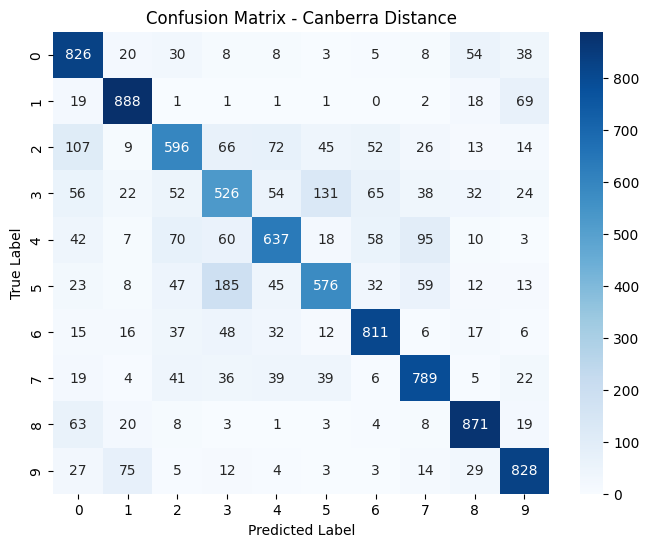

In [14]:
find_knn3()

using SkLearn Library with Bray Curtis as the distance metric

In [15]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

def find_knn4(k=10, X_train=X_train_knn_qui, X_test=X_test_knn_qui, y_train=y_train, y_test=y_test):
    # Initialize k-NN classifier with Bray-Curtis distance
    knn = KNeighborsClassifier(n_neighbors=k, metric='braycurtis')

    # Train the model
    knn.fit(X_train, y_train)

    # Predict on test data
    y_pred = knn.predict(X_test)

    # Compute and print accuracy
    accuracy = accuracy_score(y_test, y_pred)
    print(f"Accuracy: {accuracy * 100:.2f}%")

    # Compute and print confusion matrix
    conf_matrix = confusion_matrix(y_test, y_pred)
    print("Confusion Matrix:\n", conf_matrix)

    # Plot confusion matrix
    plt.figure(figsize=(8, 6))
    sns.heatmap(conf_matrix, annot=True, fmt="d", cmap="Blues",
                xticklabels=np.unique(y_test), yticklabels=np.unique(y_test))
    plt.xlabel("Predicted Label")
    plt.ylabel("True Label")
    plt.title("Confusion Matrix - Bray-Curtis Distance")
    plt.show()

Accuracy: 74.64%
Confusion Matrix:
 [[811  22  22  11  11   3  10  10  66  34]
 [  8 894   2   2   1   2   5   2  19  65]
 [ 64   9 592  47 115  57  67  18  18  13]
 [ 20  16  56 526  68 151  88  25  28  22]
 [ 26   5  49  47 719  24  71  45  10   4]
 [ 15   8  49 157  65 615  31  40  12   8]
 [  8   8  34  37  44  13 830   6  16   4]
 [ 16   6  27  41  63  47  10 764   7  19]
 [ 40  23   9   6   5   6   5   7 883  16]
 [ 24  78   5   9   5   2   8  12  27 830]]


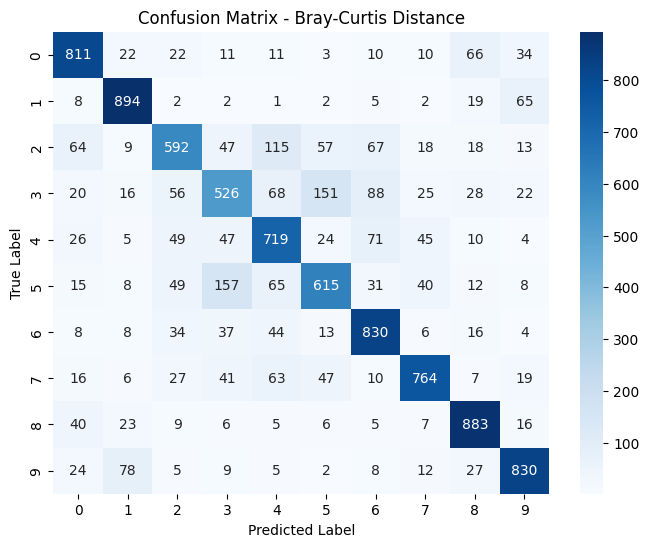

In [16]:
find_knn4()